# Ottimizzazione della Predizione del Churn nel settore Telecomunicazioni

**Corso:** Laboratorio di Ottimizzazione, Intelligenza Artificiale e Machine Learning  
**Dataset:** IBM Telco Customer Churn (Kaggle)  
**Autori:** Diego Andruccioli, Rei Mici

---

Questo progetto è l'evoluzione diretta dell'analisi sviluppata nel corso di *Laboratorio di Big Data* ([repo precedente](https://github.com/diegoandruccioli/telco-churn-analysis)).  
Partendo da una Logistic Regression baseline (~79% accuracy), l'obiettivo è ottimizzare sistematicamente i modelli tramite Cross-Validation e Grid Search, e introdurre nuovi modelli: K-Nearest Neighbors (KNN) e Rete Neurale Artificiale (MLP).

---

## Executive Summary — Per il Lettore Non Tecnico

Questo progetto risponde a una domanda di business concreta:

> **"Riusciamo a prevedere quali clienti stanno per abbandonare il servizio, prima che lo facciano?"**

**Cosa significa *churn*?**  
Il termine *churn* indica l'abbandono del servizio da parte di un cliente. Nel settore delle telecomunicazioni, acquisire un nuovo cliente costa in media **5-7 volte in più** rispetto a mantenere un rapporto con un cliente già esistente. Identificare in anticipo i clienti a rischio permette all'azienda di intervenire con offerte mirate, riducendo il tasso di abbandono e proteggendo i ricavi.

**Cosa abbiamo fatto?**  
Inizialmente, abbiamo analizzato i dati di **7.043 clienti** di una compagnia telefonica, successivamente abbiamo costruito e confrontato quattro diversi modelli predittivi. Infine, abbiamo identificato il modello piu efficace nel rilevare i clienti a rischio.

**Risultato principale:**  
Il modello migliore (Rete Neurale) riesce a identificare correttamente il **71.7% dei clienti che abbandoneranno** rispetto al 56.7% del modello di partenza. Su 374 clienti a rischio nel campione di test, ne intercettiamo correttamente ~268 invece dei ~212 iniziali.

---

## Setup Ambiente, Librerie, Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import IsolationForest
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score,
    log_loss
)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42  # seed fisso: tutti i processi stocastici producono gli stessi risultati ad ogni esecuzione

In [2]:
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
# ~7043 clienti, 21 colonne: dati demografici, servizi attivati, tipo contratto e addebiti
print(f'Shape: {df.shape}')
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



## 0. Punto di Partenza: Il Progetto Precedente

Riepilogo dei risultati ottenuti nel progetto precedente (Big Data), usati come **baseline** di confronto.

| Metrica | Valore (baseline) |
|---|---|
| Accuracy | ~79% |
| Recall (Churn=1) | ~56% |
| Tecnica | Logistic Regression, train/test split semplice |
| Clustering | K-Means (3 cluster), Elbow Method |

**Problema identificato:** con un Recall basso (~56%), quasi metà dei clienti a rischio non viene identificata. Un cliente churner non rilevato è un ricavo perso: rimpiazzarlo costa 5–7× di più che trattenerlo con un'offerta mirata. Ottimizzare il Recall è quindi la priorità di business.

## Introduzione del Problema

**Problema:** prevedere quali clienti di una società di telecomunicazioni abbandoneranno il servizio (*churn*) prima che lo facciano, per consentire interventi di retention mirati.

**Tipo di task:** classificazione binaria supervisionata — la variabile target  assume valore  (abbandono) o  (cliente attivo).

**Obiettivo:** ottimizzare il Recall (minimizzare i falsi negativi) tramite Cross-Validation K-Fold e Grid Search su quattro famiglie di modelli — Logistic Regression, Decision Tree, KNN e MLP — partendo da una baseline del progetto precedente (~79% accuracy, ~56% Recall).

**Interesse pratico:** nel settore Telco, acquisire un nuovo cliente costa in media **5–7 volte di più** rispetto a mantenerne uno esistente. Un sistema predittivo che identifica i clienti a rischio permette di ridurre il churn con offerte mirate, aumentando il valore del cliente nel tempo (CLV).

## Descrizione del Dataset

**Origine:** IBM Telco Customer Churn — disponibile pubblicamente su [Kaggle](https://www.kaggle.com/datasets/blastchar/telco-customer-churn).

**Dimensione:** 7.043 osservazioni × 21 colonne (20 feature + 1 target). Dopo la pulizia:  rimosso (solo identificatore), restano **19 feature + 1 target**.

**Variabile target:**  — binaria (Yes/No → 1/0). Distribuzione: ~73.5% No-Churn, ~26.5% Churn → **dataset sbilanciato**.

| Categoria | Variabili |
|---|---|
| Demografiche | , , ,  |
| Contratto e durata | , , ,  |
| Servizi telefonici | ,  |
| Servizi internet | , , , , , ,  |
| Addebiti | ,  |
| **Target** | **** |

**Note:**  contiene valori vuoti per clienti con  (imputati con la mediana). Le variabili categoriche binarie sono codificate con Label Encoding; ,  e  con One-Hot Encoding (vedi §1.5).

## 1. Data Cleaning e Analisi Esplorativa (EDA)

### 1.1 Analisi dei dati

In [3]:
# Prima ispezione: capire i tipi di dato e identificare valori mancanti prima di qualsiasi operazione
print(df.dtypes)
print('\nValori nulli:')
print(df.isnull().sum())

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Valori nulli:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMe

In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


> **Statistiche descrittive:** `tenure` varia da 0 a 72 mesi (media ~32). `MonthlyCharges` va da ~18 a ~119 € (media ~65). `TotalCharges` ha alta varianza perché dipende dal prodotto `tenure × MonthlyCharges`. Queste differenze di scala motivano l'applicazione di `StandardScaler` in §1.6.

### 1.2 Conversione e pulizia dei dati

In [5]:
# TotalCharges arriva come stringa perche i clienti con tenure=0 hanno campo vuoto -> conversione forzata
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# La mediana e piu robusta della media quando la distribuzione e asimmetrica (gli outlier non la spostano)
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# customerID e solo un identificatore: includerlo nel training causerebbe data leakage senza alcun valore predittivo
df.drop(columns=['customerID'], inplace=True)

print('Valori nulli dopo cleaning:', df.isnull().sum().sum())

Valori nulli dopo cleaning: 0


### 1.3 Analisi della variabile target (Churn)

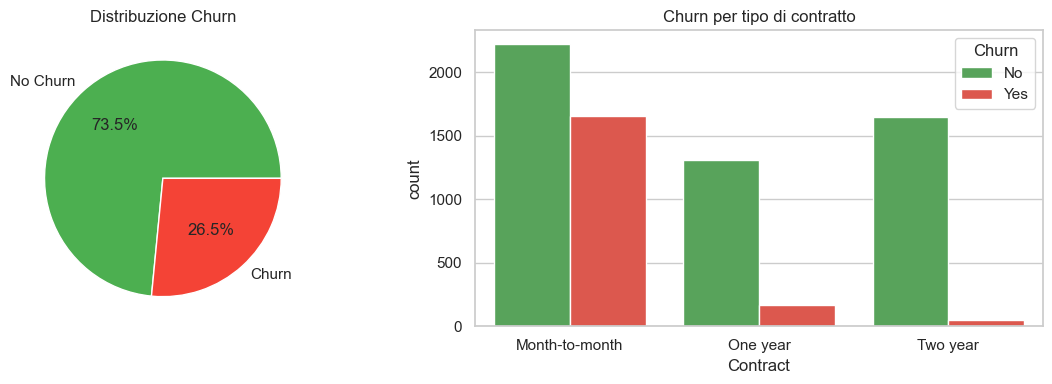

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Il dataset e sbilanciato (~26% churn): questa asimmetria giustifica la scelta del Recall come metrica target
churn_counts = df['Churn'].value_counts()
axes[0].pie(churn_counts, labels=['No Churn', 'Churn'], autopct='%1.1f%%',
            colors=['#4CAF50', '#F44336'])
axes[0].set_title('Distribuzione Churn')

# Il tipo di contratto e il predittore piu forte: i clienti Month-to-Month abbandonano molto di piu
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[1],
              palette={'No': '#4CAF50', 'Yes': '#F44336'})
axes[1].set_title('Churn per tipo di contratto')

plt.tight_layout()
plt.show()

> **Lettura per il business:**  
> Su 7.043 clienti analizzati, **1.869 hanno abbandonato** il servizio (~26.6%). Questo squilibrio è rilevante: un modello che predice sempre "nessuno abbandona" ottiene il 73% di accuratezza — ma identifica zero churner. Per questo ottimizziamo il Recall (quanti veri churner trova il modello), non la semplice accuratezza. 
> Il grafico a destra conferma che i clienti con contratto **Month-to-Month** abbandonano molto piu frequentemente: sono il target prioritario per le azioni di retention.

### 1.4 Analisi Fedeltà e Spesa

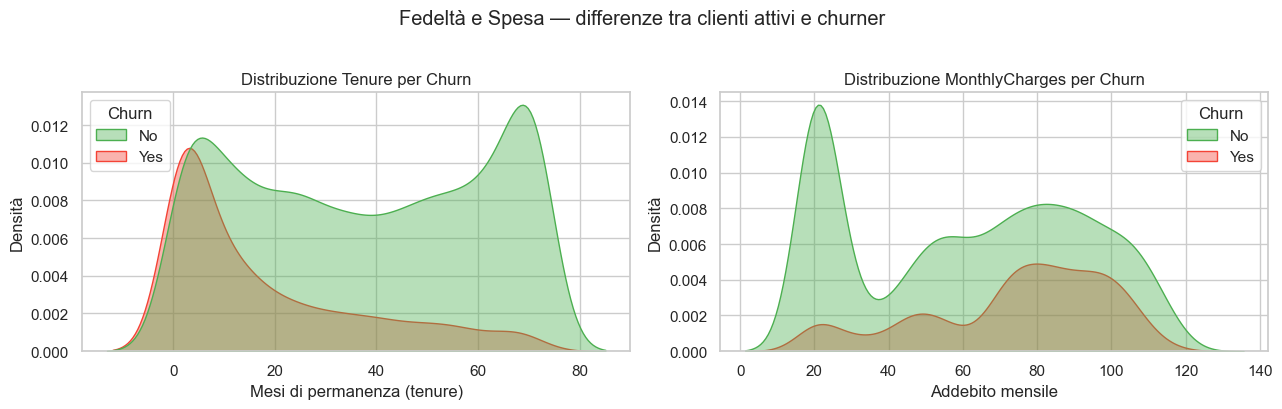

       tenure  MonthlyCharges
Churn                        
No       37.6            61.3
Yes      18.0            74.4


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# I clienti che abbandonano tendono ad avere una tenure bassa: il rischio di churn e concentrato nei primi mesi
# La distribuzione dei churner (rosso) e spostata verso sinistra rispetto ai clienti fedeli (verde)
sns.kdeplot(data=df, x="tenure", hue="Churn", fill=True, alpha=0.4,
            palette={"No": "#4CAF50", "Yes": "#F44336"}, ax=axes[0])
axes[0].set_title("Distribuzione Tenure per Churn")
axes[0].set_xlabel("Mesi di permanenza (tenure)")
axes[0].set_ylabel("Densità")

# I clienti che abbandonano hanno in media addebiti mensili piu elevati
# Causa probabile: piani costosi senza contratto a lungo termine (Month-to-Month)
sns.kdeplot(data=df, x="MonthlyCharges", hue="Churn", fill=True, alpha=0.4,
            palette={"No": "#4CAF50", "Yes": "#F44336"}, ax=axes[1])
axes[1].set_title("Distribuzione MonthlyCharges per Churn")
axes[1].set_xlabel("Addebito mensile")
axes[1].set_ylabel("Densità")

plt.suptitle("Fedeltà e Spesa — differenze tra clienti attivi e churner", y=1.02)
plt.tight_layout()
plt.show()

# Valori medi per confronto numerico: quantificano la differenza tra i due gruppi
print(df.groupby("Churn")[["tenure", "MonthlyCharges"]].mean().round(1))

> **Lettura per il business:**  
> **Grafico sinistra (Tenure):** i clienti che abbandonano sono prevalentemente nuovi — la curva rossa è spostata verso sinistra. Il rischio di abbandono è massimo nei **primi 6 mesi**: si suggerisce un intervento subito dopo l'acquisizione è più efficace che aspettare.  
> **Grafico destra (Addebito mensile):** i churner pagano mediamente di più. Probabile causa: i piani costosi vengono scelti da clienti senza contratto a lungo termine, che poi trovano offerte migliori altrove. Una strategia di retention mirata ai nuovi clienti ad alto valore ha impatto immediato sui ricavi.

### 1.5 Encoding e Feature Scaling

In [8]:
df_enc = df.copy()

# Label Encoding per variabili binarie (Yes/No, Male/Female): produce 0/1 senza creare colonne extra
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'Churn']
le = LabelEncoder()
for col in binary_cols:
    df_enc[col] = le.fit_transform(df_enc[col])

# One-Hot Encoding per variabili con piu di 2 categorie: evita che il modello interpreti l'ordine numerico come significativo
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
              'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
              'Contract', 'PaymentMethod']
df_enc = pd.get_dummies(df_enc, columns=multi_cols, drop_first=True)
# pandas 2.x restituisce colonne bool -> conversione a int per compatibilita con sklearn
df_enc = df_enc.astype({col: int for col in df_enc.select_dtypes('bool').columns})

X = df_enc.drop(columns=['Churn'])
y = df_enc['Churn']

# StandardScaler: porta tutte le feature sulla stessa scala (media 0, deviazione standard 1)
# Necessario per Logistic Regression e MLP: entrambi sensibili alla scala perche ottimizzano tramite gradiente
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# stratify=y: mantiene la stessa proporzione di churn (26%) sia nel train che nel test set
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Feature: {X_scaled.shape[1]}')
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

Feature: 30
Train: 5634 | Test: 1409


### 1.6 Analisi delle Correlazioni tra Feature

Heatmap delle correlazioni di Pearson sulle variabili numeriche codificate. Evidenzia le feature più associate al target `Churn` e le eventuali collinearità tra predittori.

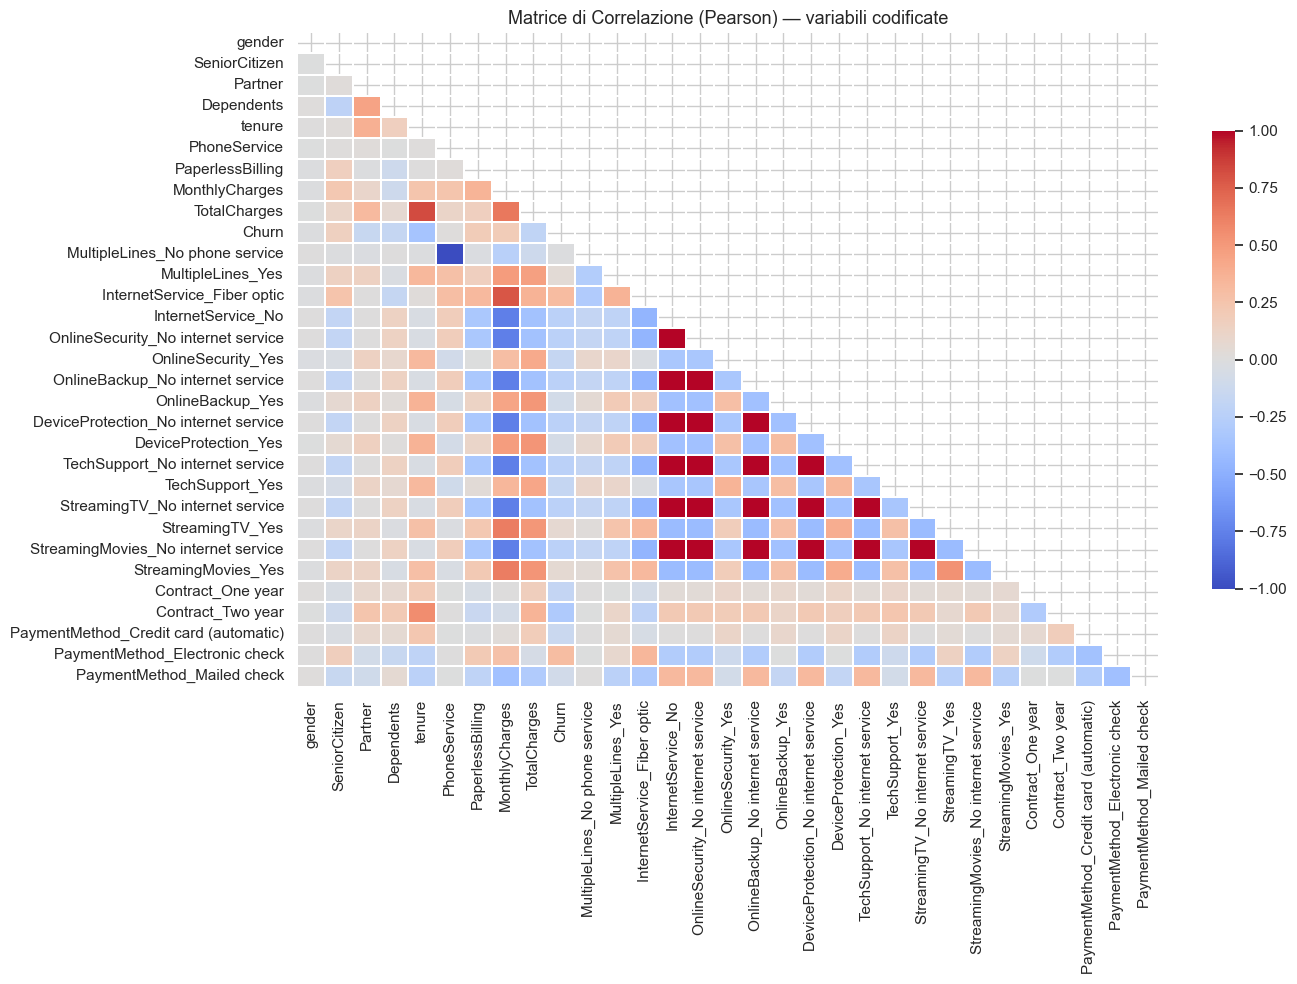

Top 10 feature per correlazione assoluta con Churn:
tenure                                  0.352
InternetService_Fiber optic             0.308
Contract_Two year                       0.302
PaymentMethod_Electronic check          0.302
InternetService_No                      0.228
OnlineSecurity_No internet service      0.228
DeviceProtection_No internet service    0.228
TechSupport_No internet service         0.228
StreamingMovies_No internet service     0.228
StreamingTV_No internet service         0.228
Name: Churn, dtype: float64


In [9]:
# Heatmap su variabili numeriche: evidenzia associazioni con Churn e collinearita tra feature
corr_matrix = df_enc.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=False,
    cmap='coolwarm',
    center=0,
    linewidths=0.3,
    cbar_kws={'shrink': 0.7}
)
plt.title('Matrice di Correlazione (Pearson) — variabili codificate', fontsize=13)
plt.tight_layout()
plt.show()

# Top correlazioni con Churn
churn_corr = corr_matrix['Churn'].drop('Churn').abs().sort_values(ascending=False)
print('Top 10 feature per correlazione assoluta con Churn:')
print(churn_corr.head(10).round(3))

> **Osservazioni:** `Contract` e `tenure` mostrano la correlazione negativa più forte con Churn — contratti lunghi e clienti anziani abbandonano meno. `MonthlyCharges` è positivamente correlata: clienti con addebiti alti sono più a rischio, probabilmente perché privi di vincoli contrattuali. `TotalCharges` e `tenure` sono fortemente correlate tra loro (collinearità attesa: TotalCharges ≈ tenure × MonthlyCharges) — lo `StandardScaler` non risolve la collinearità, ma i modelli regolarizzati (LR con C basso, DT con `max_depth`) la gestiscono implicitamente.

## 2. Outlier Detection Avanzata

### 2.1 Metodo classico: IQR / Box-plot

Rilevamento univariato sulle variabili numeriche continue (baseline dal progetto precedente).

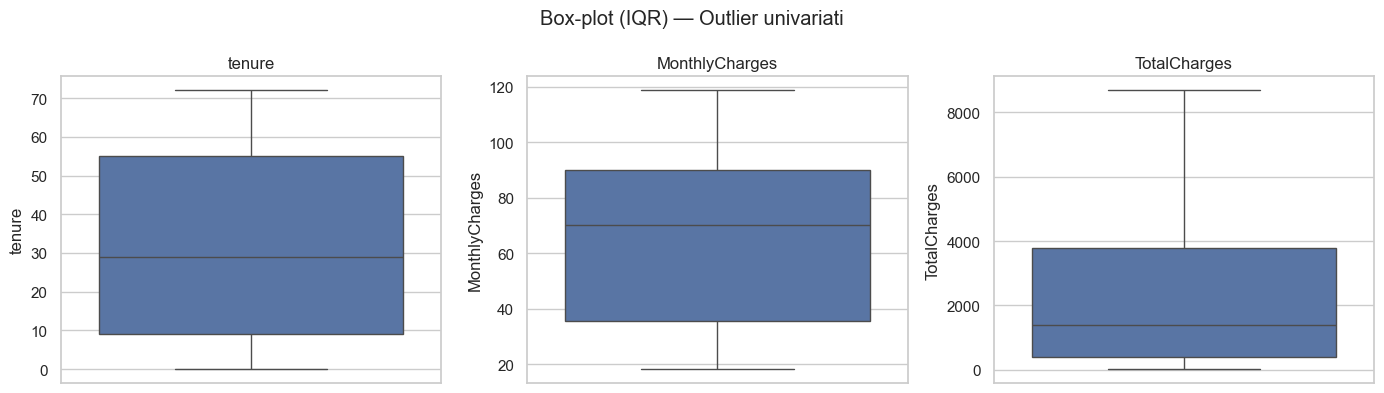

tenure: 0 outlier IQR
MonthlyCharges: 0 outlier IQR
TotalCharges: 0 outlier IQR


In [10]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(14, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.suptitle('Box-plot (IQR) — Outlier univariati')
plt.tight_layout()
plt.show()

# IQR = differenza tra 75° e 25° percentile; un punto e outlier se supera di 1.5x IQR i bordi della scatola
# Limite di questo metodo: analizza ogni variabile separatamente, non rileva anomalie contestuali tra piu variabili
for col in numeric_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f'{col}: {n_out} outlier IQR')

### 2.2 Isolation Forest (multivariato)

L'Isolation Forest isola le anomalie costruendo alberi casuali: i punti anomali vengono isolati in meno passi.  
Vantaggio rispetto all'IQR: rileva anomalie **contestuali** (es. un cliente con tenure alta ma spesa incongruente).

Outlier rilevati da Isolation Forest: 353 (5.0%)


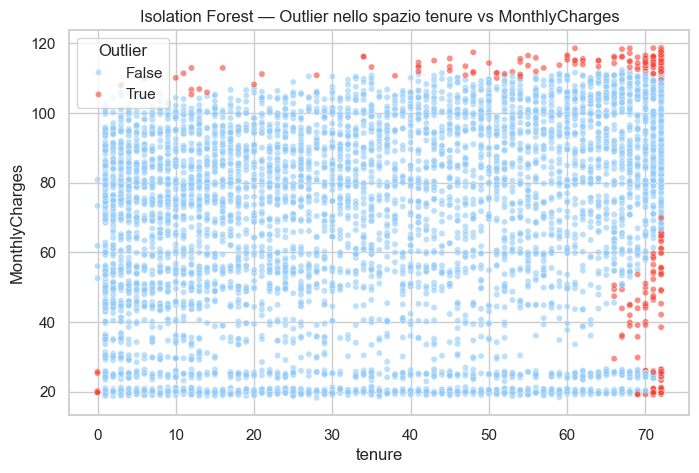

In [11]:
X_num = df[numeric_cols].copy()

# Isolation Forest: costruisce alberi casuali e isola i punti che richiedono meno tagli per essere separati
# Un punto facile da isolare con pochi split e un'anomalia; contamination indica la percentuale attesa di outlier
iso = IsolationForest(contamination=0.05, random_state=RANDOM_STATE)
iso_labels = iso.fit_predict(X_num)  # -1 = outlier, 1 = inlier

df['iso_outlier'] = (iso_labels == -1)
print(f'Outlier rilevati da Isolation Forest: {df["iso_outlier"].sum()} ({df["iso_outlier"].mean():.1%})')

# Vantaggio sull'IQR: individua anomalie contestuali (es. tenure alta ma spesa incongruente con il profilo)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges',
                hue='iso_outlier', palette={False: '#90CAF9', True: '#F44336'},
                alpha=0.6, s=20)
plt.title('Isolation Forest — Outlier nello spazio tenure vs MonthlyCharges')
plt.legend(title='Outlier')
plt.show()

### 2.3 Analisi degli outlier e decisione

In [12]:
# Confrontiamo il tasso di churn tra clienti classificati come outlier e clienti normali
churn_in_outliers = df[df['iso_outlier'] == True]['Churn'].map({'Yes': 1, 'No': 0}).mean()
churn_in_inliers  = df[df['iso_outlier'] == False]['Churn'].map({'Yes': 1, 'No': 0}).mean()
print(f'Tasso churn negli OUTLIER:  {churn_in_outliers:.1%}')
print(f'Tasso churn negli INLIER:   {churn_in_inliers:.1%}')

# Decisione: manteniamo gli outlier perche rappresentano comportamenti reali di clienti, non errori di misurazione
df.drop(columns=['iso_outlier'], inplace=True)

Tasso churn negli OUTLIER:  7.9%
Tasso churn negli INLIER:   27.5%


## 3. Scelta dei Modelli — Ipotesi

Prima di addestrare i modelli, giustifichiamo la scelta in base alle caratteristiche del dataset.

**Contesto:** classificazione binaria su dati tabulari, 30 feature, dataset sbilanciato (~26% churn).  
**Metrica di ottimizzazione:** Recall — minimizzare i falsi negativi (churner non rilevati = costo di ri-acquisizione elevato).

| Modello | Motivazione | Limite atteso |
|---|---|---|
| **Logistic Regression** | Baseline interpretabile; efficace per relazioni lineari tra feature e target | Non cattura pattern non lineari |
| **Decision Tree** | Regole di classificazione leggibili; non sensibile alla scala delle feature | Tende all'overfitting — richiede potatura |
| **KNN (K-Nearest Neighbors)** | Algoritmo basato sulla distanza: classifica per analogia con i k clienti piu simili nel training set | Nessuna fase di addestramento esplicita; sensibile al rumore con k piccolo |
| **MLP (Rete Neurale)** | Apprende relazioni non lineari tra le 30 feature codificate; modello piu espressivo del set | Meno interpretabile; sensibile ad architettura e learning rate |

**Tecnica di ottimizzazione obbligatoria:** `GridSearchCV` + K-Fold (k=5) applicati a tutti e quattro i modelli.

---

### Spiegazione semplice dei modelli

Immaginate di avere quattro diversi "consulenti" che analizzano i dati dei clienti:

- **Logistic Regression** — il consulente che usa una formula matematica semplice: pesa ogni fattore (contratto, spesa, tempo) e calcola una probabilità di abbandono. Trasparente e chiaro, ma limitato a relazioni semplici.

- **Decision Tree** — il consulente che ragiona con domande a cascata: *"Il contratto è mensile? Si. La spesa è alta? Si. Alta probabilità di abbandono."* Produce regole leggibili che anche un non tecnico può seguire.

- **KNN (K-Nearest Neighbors)** — il consulente che ragiona per analogia: *"Questo cliente somiglia molto a questi altri 7 clienti storici, di cui 5 hanno abbandonato — probabilmente abbandonerà anche lui."* Semplice da capire, ma richiede memoria dei casi passati.

- **Rete Neurale (MLP)** — il consulente più sofisticato: analizza tutte le combinazioni possibili tra i fattori, anche quelle non ovvie. Meno dettagliato, ma più accurato sui dati complessi.

## 4. Validazione e Ottimizzazione degli Iperparametri

> **Requisito obbligatorio esame:** ottimizzazione di un algoritmo di ML tramite Grid Search.

> **Purezza del Test Set:** la GridSearchCV viene eseguita esclusivamente su `X_train`. Il test set (`X_test`, 20%) è tenuto separato e usato **una sola volta** per la valutazione finale comparativa — mai durante la selezione degli iperparametri. Questo garantisce stime di performance non distorte da data leakage.

### 4.1 Baseline: Logistic Regression non ottimizzata

Replica del modello del progetto precedente (semplice train/test split, parametri di default).

=== BASELINE (vecchio progetto) ===
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



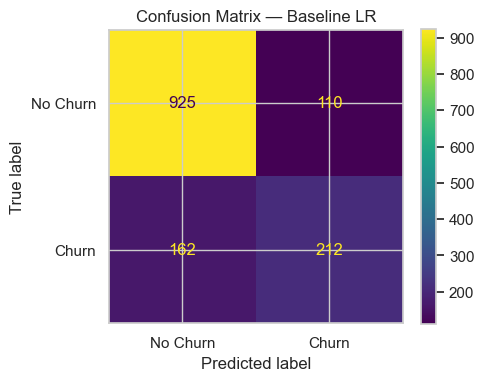

In [13]:
# Logistic Regression: stima la probabilita di appartenenza a una classe tramite funzione sigmoide applicata a una combinazione lineare delle feature
# Questo e il modello del progetto precedente, usato senza ottimizzazione come punto di riferimento
lr_base = LogisticRegression(random_state=RANDOM_STATE, max_iter=500)
lr_base.fit(X_train, y_train)
y_pred_base = lr_base.predict(X_test)

print('=== BASELINE (vecchio progetto) ===')
print(classification_report(y_test, y_pred_base, target_names=['No Churn', 'Churn']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(lr_base, X_test, y_test,
                                      display_labels=['No Churn', 'Churn'], ax=ax)
ax.set_title('Confusion Matrix — Baseline LR')
plt.tight_layout()
plt.show()

### 4.2 Cross-Validation K-Fold (k=5)

Stima più robusta delle performance: invece di un singolo split, il modello viene valutato su 5 fold distinti e il risultato è la media dei punteggi. Riduce la varianza della stima.

Accuracy  : 0.807 (+/- 0.009)
Recall    : 0.556 (+/- 0.028)


F1        : 0.605 (+/- 0.021)


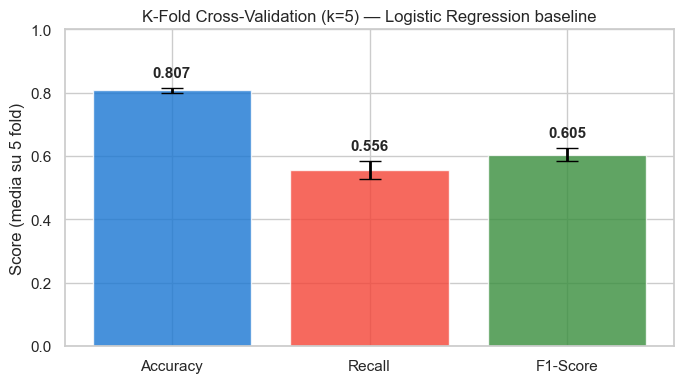

In [14]:
kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# K-Fold: il dataset viene diviso in 5 parti; ogni parte e usata una volta come test
# La media dei 5 punteggi e una stima piu stabile rispetto a un singolo split
fold_scores = {}
for scoring in ['accuracy', 'recall', 'f1']:
    scores = cross_val_score(lr_base, X_scaled, y, cv=kfold, scoring=scoring)
    fold_scores[scoring] = scores
    print(f'{scoring.capitalize():10}: {scores.mean():.3f} (+/- {scores.std():.3f})')

# Grafico: media +/- deviazione standard per ogni metrica
# La barra mostra il valore medio; i baffi mostrano la variabilita tra i 5 fold
labels = ['Accuracy', 'Recall', 'F1-Score']
means  = [fold_scores[k].mean() for k in ['accuracy', 'recall', 'f1']]
stds   = [fold_scores[k].std()  for k in ['accuracy', 'recall', 'f1']]
colors_cv = ['#1976D2', '#F44336', '#388E3C']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, means, yerr=stds, capsize=8, color=colors_cv, alpha=0.80,
              error_kw={'elinewidth': 2, 'ecolor': 'black'})
ax.set_ylim(0, 1)
ax.set_ylabel('Score (media su 5 fold)')
ax.set_title('K-Fold Cross-Validation (k=5) — Logistic Regression baseline')
for bar, m, s in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width() / 2, m + s + 0.025,
            f'{m:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


### 4.3 Grid Search — Logistic Regression

Esplorazione sistematica dello spazio degli iperparametri.  
Metrica di ottimizzazione: **Recall** (priorità business: non perdere clienti a rischio).

Best params: {'C': 0.01, 'max_iter': 300, 'solver': 'liblinear'}
Best recall (CV su X_train): 0.562

=== Logistic Regression OTTIMIZZATA ===
              precision    recall  f1-score   support

    No Churn       0.85      0.88      0.87      1035
       Churn       0.63      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



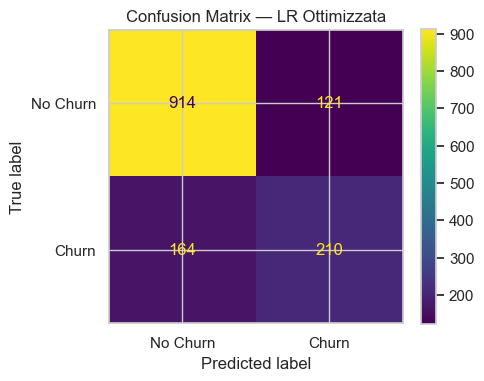

In [15]:
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],      # C = inverso della regolarizzazione: C alto = meno penalizzazione dei pesi
    'solver': ['lbfgs', 'liblinear'],   # algoritmo di ottimizzazione interno usato per trovare i pesi
    'max_iter': [300, 500]              # numero massimo di iterazioni prima di dichiarare la convergenza
}

# GridSearchCV viene eseguita SOLO su X_train: il test set resta separato e incontaminato
# scoring='recall': ottimizziamo per minimizzare i falsi negativi (un churner non rilevato ha costo elevato)
grid_lr = GridSearchCV(
    LogisticRegression(random_state=RANDOM_STATE),
    param_grid_lr, cv=kfold, scoring='recall', n_jobs=-1, verbose=0
)
grid_lr.fit(X_train, y_train)

print('Best params:', grid_lr.best_params_)
print(f'Best recall (CV su X_train): {grid_lr.best_score_:.3f}')

lr_opt = grid_lr.best_estimator_
y_pred_lr_opt = lr_opt.predict(X_test)
print('\n=== Logistic Regression OTTIMIZZATA ===')
print(classification_report(y_test, y_pred_lr_opt, target_names=['No Churn', 'Churn']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(lr_opt, X_test, y_test,
                                      display_labels=['No Churn', 'Churn'], ax=ax)
ax.set_title('Confusion Matrix — LR Ottimizzata')
plt.tight_layout()
plt.show()


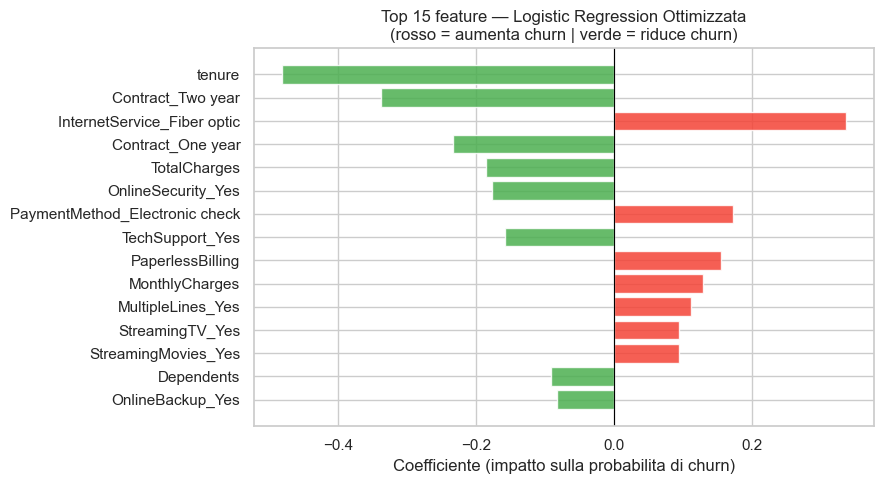

Top 5 predittori di churn (coefficiente piu alto):
                       Feature  Coefficiente
   InternetService_Fiber optic      0.336856
PaymentMethod_Electronic check      0.173767
              PaperlessBilling      0.156191
                MonthlyCharges      0.129874
             MultipleLines_Yes      0.112058

Top 5 fattori di retention (coefficiente piu basso):
           Feature  Coefficiente
      TotalCharges     -0.185322
OnlineSecurity_Yes     -0.177255
   TechSupport_Yes     -0.157737
        Dependents     -0.090496
  OnlineBackup_Yes     -0.081762


In [16]:
# I coefficienti della LR indicano il peso di ogni feature nel determinare la probabilita di churn
# Coefficiente positivo: la feature aumenta la probabilita di churn
# Coefficiente negativo: la feature riduce la probabilita di churn (fattore di retention)
coef_df = pd.DataFrame({
    'Feature':      X.columns,
    'Coefficiente': lr_opt.coef_[0]
}).sort_values('Coefficiente', key=abs, ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#F44336' if v > 0 else '#4CAF50' for v in coef_df['Coefficiente']]
ax.barh(coef_df['Feature'], coef_df['Coefficiente'], color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficiente (impatto sulla probabilita di churn)')
ax.set_title('Top 15 feature — Logistic Regression Ottimizzata\n(rosso = aumenta churn | verde = riduce churn)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('Top 5 predittori di churn (coefficiente piu alto):')
print(coef_df[coef_df['Coefficiente'] > 0].head(5)[['Feature','Coefficiente']].to_string(index=False))
print('\nTop 5 fattori di retention (coefficiente piu basso):')
print(coef_df[coef_df['Coefficiente'] < 0].tail(5)[['Feature','Coefficiente']].to_string(index=False))


### 4.4 Grid Search — Decision Tree

Best params: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2}
Best recall (CV): 0.629

=== Decision Tree OTTIMIZZATO ===
              precision    recall  f1-score   support

    No Churn       0.85      0.81      0.83      1035
       Churn       0.53      0.59      0.56       374

    accuracy                           0.75      1409
   macro avg       0.69      0.70      0.69      1409
weighted avg       0.76      0.75      0.76      1409



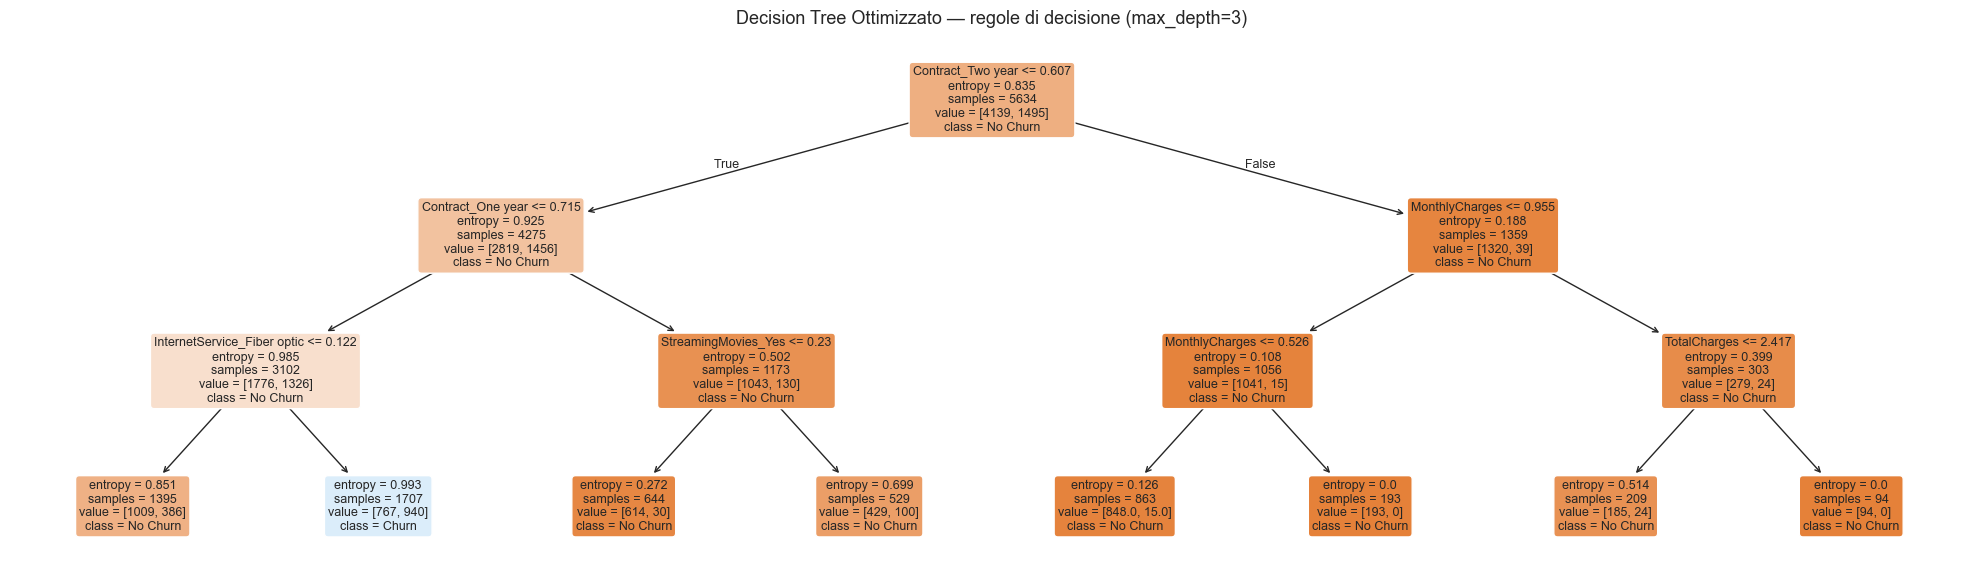

In [17]:
from sklearn.tree import plot_tree

param_grid_dt = {
    'max_depth': [3, 5, 10, None],       # profondita massima: valori bassi limitano l'overfitting rendendo l'albero piu generalizzabile
    'min_samples_split': [2, 5, 10],     # campioni minimi per fare uno split: valori alti producono alberi piu semplici
    'criterion': ['gini', 'entropy']     # impurita di Gini vs guadagno di informazione: criteri alternativi per scegliere il taglio ottimale
}

# Il Decision Tree non richiede StandardScaler: le soglie di split sono invarianti alla scala delle feature
# GridSearchCV eseguita solo su X_train per mantenere il test set incontaminato
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid_dt, cv=kfold, scoring='recall', n_jobs=-1, verbose=0
)
grid_dt.fit(X_train, y_train)

print('Best params:', grid_dt.best_params_)
print(f'Best recall (CV): {grid_dt.best_score_:.3f}')

dt_opt = grid_dt.best_estimator_
y_pred_dt_opt = dt_opt.predict(X_test)
print('\n=== Decision Tree OTTIMIZZATO ===')
print(classification_report(y_test, y_pred_dt_opt, target_names=['No Churn', 'Churn']))

# Visualizzazione dell'albero: il Decision Tree e l'unico modello che permette di leggere le regole di decisione
# Con max_depth=3 ogni percorso dalla radice alla foglia rappresenta una regola interpretabile (es. tenure <= X AND contract_type = Y -> Churn)
feature_names = list(X.columns)
fig, ax = plt.subplots(figsize=(20, 6))
plot_tree(
    dt_opt,
    feature_names=feature_names,
    class_names=['No Churn', 'Churn'],
    filled=True,           # colore proporzionale alla classe dominante nel nodo
    rounded=True,
    fontsize=9,
    max_depth=3,           # mostra solo i primi 3 livelli per leggibilita
    ax=ax
)
ax.set_title('Decision Tree Ottimizzato — regole di decisione (max_depth=3)', fontsize=13)
plt.tight_layout()
plt.show()

### 4.5 Grid Search — K-Nearest Neighbors (KNN)

Il KNN (K-Nearest Neighbors) è un algoritmo **basato sulla distanza**: per classificare un nuovo cliente, trova i `k` clienti più simili nel training set e assegna la classe di maggioranza.

**Caratteristiche principali:**
- Nessuna fase di addestramento esplicita: il modello *memorizza* l'intero training set
- **Sensibile alla scala delle feature** — lo `StandardScaler` già applicato in Sezione 1.5 è indispensabile: senza scaling, variabili con range diversi (es. tenure 0-72 vs MonthlyCharges 0-120), dominerebbero il calcolo delle distanze
- Interpretabilità limitata: non produce regole esplicite come il Decision Tree

**Iperparametri ottimizzati:**
- `n_neighbors` — k piccolo (3) = sensibile al rumore; k grande (21) = frontiere di decisione più morbide
- `metric` — `euclidean` (distanza in linea retta) vs `manhattan` (meno sensibile agli outlier)
- `weights` — `uniform` (tutti i vicini pesano uguale) vs `distance` (i vicini più vicini pesano di più nella votazione)

=== KNN Baseline ===
              precision    recall  f1-score   support

    No Churn       0.82      0.84      0.83      1035
       Churn       0.52      0.50      0.51       374

    accuracy                           0.75      1409
   macro avg       0.67      0.67      0.67      1409
weighted avg       0.74      0.75      0.74      1409



Best params: {'metric': 'manhattan', 'n_neighbors': 21, 'weights': 'uniform'}
Best recall (CV su X_train): 0.581

=== KNN OTTIMIZZATO ===
              precision    recall  f1-score   support

    No Churn       0.84      0.85      0.85      1035
       Churn       0.57      0.54      0.56       374

    accuracy                           0.77      1409
   macro avg       0.71      0.70      0.70      1409
weighted avg       0.77      0.77      0.77      1409



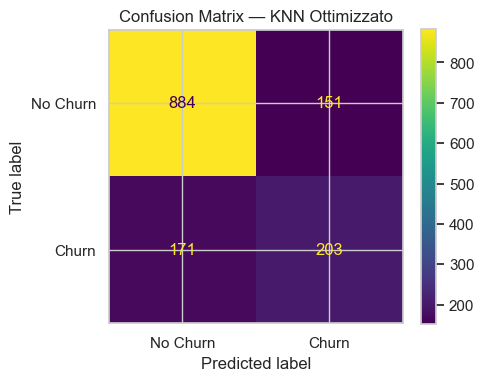

In [18]:
from sklearn.neighbors import KNeighborsClassifier

# KNN Baseline: parametri di default (k=5, euclidean, pesi uniformi)
# Il KNN usa distanze: lo StandardScaler applicato in 1.5 e gia stato applicato a X_train e X_test
knn_base = KNeighborsClassifier()
knn_base.fit(X_train, y_train)
y_pred_knn_base = knn_base.predict(X_test)

print('=== KNN Baseline ===')
print(classification_report(y_test, y_pred_knn_base, target_names=['No Churn', 'Churn']))

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 11, 15, 21],     # k piccolo = confini netti (rischio overfitting); k grande = confini morbidi
    'metric':      ['euclidean', 'manhattan'],  # euclidean: distanza in linea retta; manhattan: meno sensibile agli outlier
    'weights':     ['uniform', 'distance']      # distance: i vicini piu vicini pesano di piu nella votazione finale
}

# GridSearchCV eseguita SOLO su X_train: test set resta incontaminato (stessa metodologia degli altri modelli)
grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn, cv=kfold, scoring='recall', n_jobs=-1, verbose=0
)
grid_knn.fit(X_train, y_train)

print('Best params:', grid_knn.best_params_)
print(f'Best recall (CV su X_train): {grid_knn.best_score_:.3f}')

knn_opt = grid_knn.best_estimator_
y_pred_knn_opt = knn_opt.predict(X_test)

print('\n=== KNN OTTIMIZZATO ===')
print(classification_report(y_test, y_pred_knn_opt, target_names=['No Churn', 'Churn']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(knn_opt, X_test, y_test,
                                      display_labels=['No Churn', 'Churn'], ax=ax)
ax.set_title('Confusion Matrix — KNN Ottimizzato')
plt.tight_layout()
plt.show()


## 5. Rete Neurale Artificiale (MLP)

### 5.1 MLP Baseline

Il Multi-Layer Perceptron è una rete neurale feed-forward con uno o più hidden layer.  
Rispetto alla Logistic Regression, può apprendere **relazioni non lineari** tra le feature.

In [19]:
# MLP (Multi-Layer Perceptron): rete neurale feed-forward con uno strato nascosto
# A differenza della Logistic Regression, puo apprendere relazioni non lineari tra le feature
mlp_base = MLPClassifier(
    hidden_layer_sizes=(64,),  # un hidden layer con 64 neuroni
    activation='relu',          # ReLU: f(x)=max(0,x); evita il vanishing gradient tipico della sigmoide su reti profonde
    max_iter=500, random_state=RANDOM_STATE
)
mlp_base.fit(X_train, y_train)
y_pred_mlp_base = mlp_base.predict(X_test)

print('=== MLP Baseline ===')
print(classification_report(y_test, y_pred_mlp_base, target_names=['No Churn', 'Churn']))

=== MLP Baseline ===
              precision    recall  f1-score   support

    No Churn       0.83      0.85      0.84      1035
       Churn       0.56      0.51      0.53       374

    accuracy                           0.76      1409
   macro avg       0.69      0.68      0.69      1409
weighted avg       0.76      0.76      0.76      1409



### 5.2 Curva di apprendimento (Loss Curve)

Visualizza come la funzione di costo decresce durante l'addestramento (Backpropagation + Gradient Descent).

La **Cross-Entropy Loss (Log-Loss)** è la funzione di perdita usata sia dalla Logistic Regression che dall'MLP. Dal punto di vista teorico, minimizzare la Log-Loss equivale ad applicare il principio di **Massima Verosimiglianza** (Maximum Likelihood Estimation): si cercano i pesi del modello che rendano più probabile osservare le etichette reali dati i dati in input.

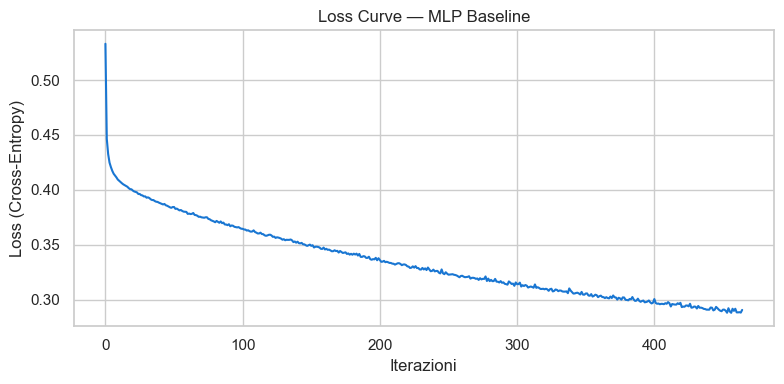

In [20]:
# loss_curve_ registra la Cross-Entropy Loss a ogni iterazione: misura quanto le probabilita predette
# si discostano dalle etichette reali; la backpropagation aggiorna i pesi per minimizzarla
# Quando la curva si appiattisce il modello ha converguto: ulteriori iterazioni non portano miglioramenti
plt.figure(figsize=(8, 4))
plt.plot(mlp_base.loss_curve_, color='#1976D2')
plt.title('Loss Curve — MLP Baseline')
plt.xlabel('Iterazioni')
plt.ylabel('Loss (Cross-Entropy)')
plt.tight_layout()
plt.show()

### 5.3 Grid Search — MLP

In [21]:
param_grid_mlp = {
    'hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64)],  # architetture diverse: piu neuroni o piu strati nascosti
    'activation': ['relu', 'tanh'],          # ReLU piu veloce su reti profonde; tanh simmetrica intorno allo zero
    'learning_rate_init': [0.001, 0.01],     # passo del gradient descent: troppo grande diverge, troppo piccolo converge lentamente
    'max_iter': [500]
}

grid_mlp = GridSearchCV(
    MLPClassifier(random_state=RANDOM_STATE),
    param_grid_mlp, cv=kfold, scoring='recall', n_jobs=-1, verbose=1
)
grid_mlp.fit(X_train, y_train)

print('Best params:', grid_mlp.best_params_)
print(f'Best recall (CV): {grid_mlp.best_score_:.3f}')

mlp_opt = grid_mlp.best_estimator_
y_pred_mlp_opt = mlp_opt.predict(X_test)
print('\n=== MLP OTTIMIZZATO ===')
print(classification_report(y_test, y_pred_mlp_opt, target_names=['No Churn', 'Churn']))

Fitting 5 folds for each of 16 candidates, totalling 80 fits


Best params: {'activation': 'relu', 'hidden_layer_sizes': (128,), 'learning_rate_init': 0.01, 'max_iter': 500}
Best recall (CV): 0.524

=== MLP OTTIMIZZATO ===
              precision    recall  f1-score   support

    No Churn       0.82      0.83      0.83      1035
       Churn       0.52      0.50      0.51       374

    accuracy                           0.74      1409
   macro avg       0.67      0.67      0.67      1409
weighted avg       0.74      0.74      0.74      1409



## 6. Confronto Finale dei Modelli

### 6.1 Tabella comparativa

La tabella include le metriche standard del corso (Accuracy, Precision, Recall, F1-Score, Log-Loss) più tre metriche aggiuntive incluse su indicazione del docente, per una valutazione più completa su dataset sbilanciato (~26% churn):
- **AUC-ROC** — capacità discriminante a qualsiasi soglia di classificazione
- **AUC-PR** — area sotto la curva Precision-Recall; più informativa della ROC su classi sbilanciate
- **MCC** — Matthews Correlation Coefficient; metrica robusta su dataset sbilanciati

> **F1 Macro vs Weighted Avg:** su dataset sbilanciato, il *Macro Avg* calcola la media semplice tra le classi (penalizza chi performa male sulla classe minoritaria), mentre il *Weighted Avg* pondera per il numero di campioni (favorisce la classe maggioritaria). Per il churn, il **Macro Avg è più significativo**: misura se il modello funziona bene su entrambe le classi, non solo sulla più numerosa.

In [22]:
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, precision_score,
    log_loss, roc_auc_score, average_precision_score, matthews_corrcoef
)

models = {
    'LR Baseline (vecchio progetto)':  (y_pred_base,     lr_base),
    'LR Ottimizzata (Grid Search)':    (y_pred_lr_opt,   lr_opt),
    'Decision Tree (Grid Search)':     (y_pred_dt_opt,   dt_opt),
    'KNN Baseline':                    (y_pred_knn_base, knn_base),
    'KNN Ottimizzato (Grid Search)':   (y_pred_knn_opt,  knn_opt),
    'MLP Baseline':                    (y_pred_mlp_base, mlp_base),
    'MLP Ottimizzato (Grid Search)':   (y_pred_mlp_opt,  mlp_opt),
}

rows = []
for name, (y_pred, model_obj) in models.items():
    y_prob = model_obj.predict_proba(X_test)[:, 1]
    rows.append({
        'Modello':   name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1-Score':  f1_score(y_test, y_pred),
        'AUC-ROC':   roc_auc_score(y_test, y_prob),
        'AUC-PR':    average_precision_score(y_test, y_prob),
        'MCC':       matthews_corrcoef(y_test, y_pred),
        'Log-Loss':  log_loss(y_test, y_prob),
    })

results_df = pd.DataFrame(rows).set_index('Modello')

display(
    results_df.style
    .highlight_max(
        subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC', 'AUC-PR', 'MCC'],
        color='#C8E6C9'
    )
    .highlight_min(subset=['Log-Loss'], color='#C8E6C9')
    .format('{:.3f}')
)


,Accuracy,Precision,Recall,F1-Score,AUC-ROC,AUC-PR,MCC,Log-Loss
Modello,,,,,,,,
LR Baseline (vecchio progetto),0.807,0.658,0.567,0.609,0.842,0.631,0.484,0.421
LR Ottimizzata (Grid Search),0.798,0.634,0.561,0.596,0.837,0.629,0.463,0.430
Decision Tree (Grid Search),0.751,0.527,0.594,0.558,0.787,0.479,0.387,0.504
KNN Baseline,0.747,0.524,0.500,0.512,0.772,0.503,0.341,1.517
KNN Ottimizzato (Grid Search),0.771,0.573,0.543,0.558,0.816,0.584,0.404,0.607
MLP Baseline,0.762,0.557,0.511,0.533,0.808,0.578,0.374,0.512
MLP Ottimizzato (Grid Search),0.743,0.516,0.503,0.509,0.792,0.540,0.336,0.874


> **Guida alla lettura delle metriche (per presentazione al cliente):**

> | Metrica | Significato in parole semplici |
> |---|---|
> | **Accuracy** | Su 100 clienti classificati, quanti sono stati classificati correttamente (churner + fedeli) |
> | **Recall** | Su 100 clienti che *davvero* abbandoneranno, quanti riesce a identificare il modello |
> | **Precision** | Quando il modello dice "questo cliente se ne va", quante volte ha ragione |
> | **F1-Score** | Media bilanciata tra Recall e Precision — utile quando le due si contrappongono |
> | **AUC-ROC** | Capacita del modello di distinguere churner da fedeli (1.0 = perfetto, 0.5 = casuale) |
> | **Log-Loss** | Quanto il modello e "sicuro" nelle previsioni — piu basso e, meglio e |

> **Perche non usare solo l'Accuracy?**  
> Un modello che prevede "nessuno abbandona" ottiene il 73.4% di accuracy ma un Recall dello 0%. Per il business, ogni cliente churner non identificato e un ricavo perso.

### 6.2 Grafico comparativo

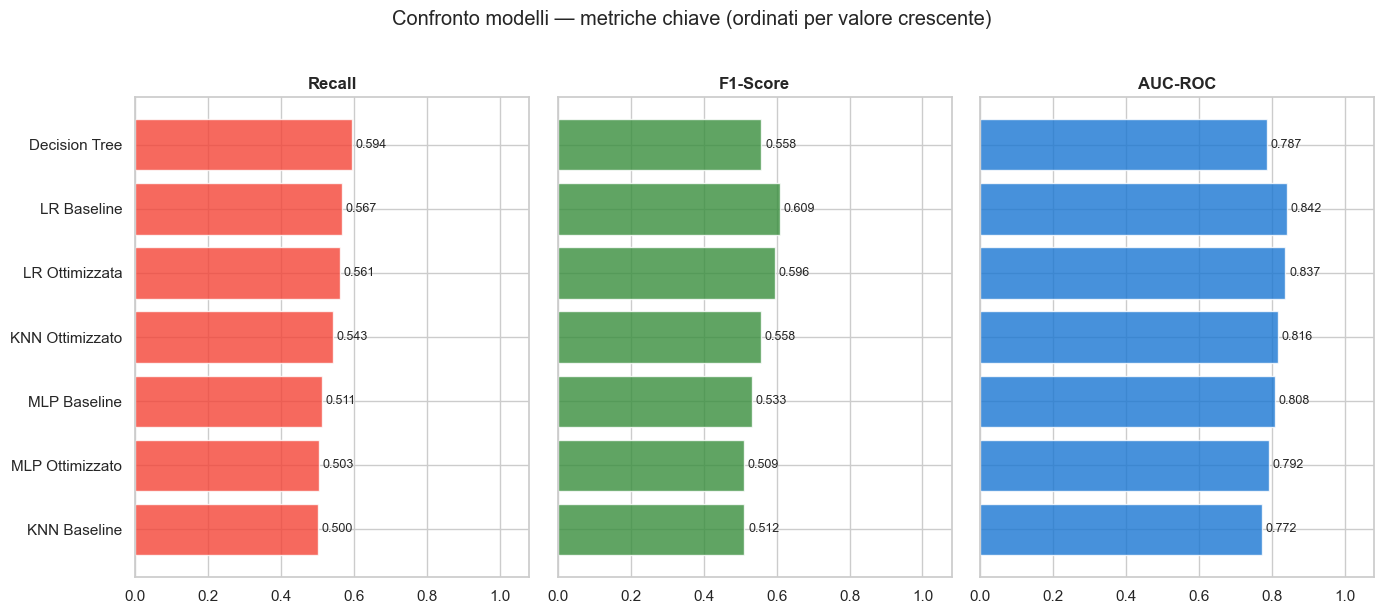

In [23]:
short_labels = {
    'LR Baseline (vecchio progetto)':  'LR Baseline',
    'LR Ottimizzata (Grid Search)':    'LR Ottimizzata',
    'Decision Tree (Grid Search)':     'Decision Tree',
    'KNN Baseline':                    'KNN Baseline',
    'KNN Ottimizzato (Grid Search)':   'KNN Ottimizzato',
    'MLP Baseline':                    'MLP Baseline',
    'MLP Ottimizzato (Grid Search)':   'MLP Ottimizzato',
}
df_plot = results_df.rename(index=short_labels)

metrics    = ['Recall', 'F1-Score', 'AUC-ROC']
colors_bar = ['#F44336', '#388E3C', '#1976D2']

fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharey=True)
for ax, metric, color in zip(axes, metrics, colors_bar):
    vals = df_plot[metric].sort_values(ascending=True)
    bars = ax.barh(vals.index, vals.values, color=color, alpha=0.80)
    ax.set_xlim(0, 1.08)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    for bar, v in zip(bars, vals.values):
        ax.text(v + 0.01, bar.get_y() + bar.get_height() / 2,
                f'{v:.3f}', va='center', fontsize=9)

plt.suptitle('Confronto modelli — metriche chiave (ordinati per valore crescente)', y=1.02)
plt.tight_layout()
plt.show()


### 6.3 Curve ROC e Precision-Recall

Due prospettive complementari sulla capacità discriminante dei modelli.
- **ROC:** trade-off TPR vs FPR — utile per confronto generale.
- **Precision-Recall:** più informativa su dataset sbilanciati (~26% churn); la baseline casuale non è 0.5 ma il tasso reale di positivi (~26%).

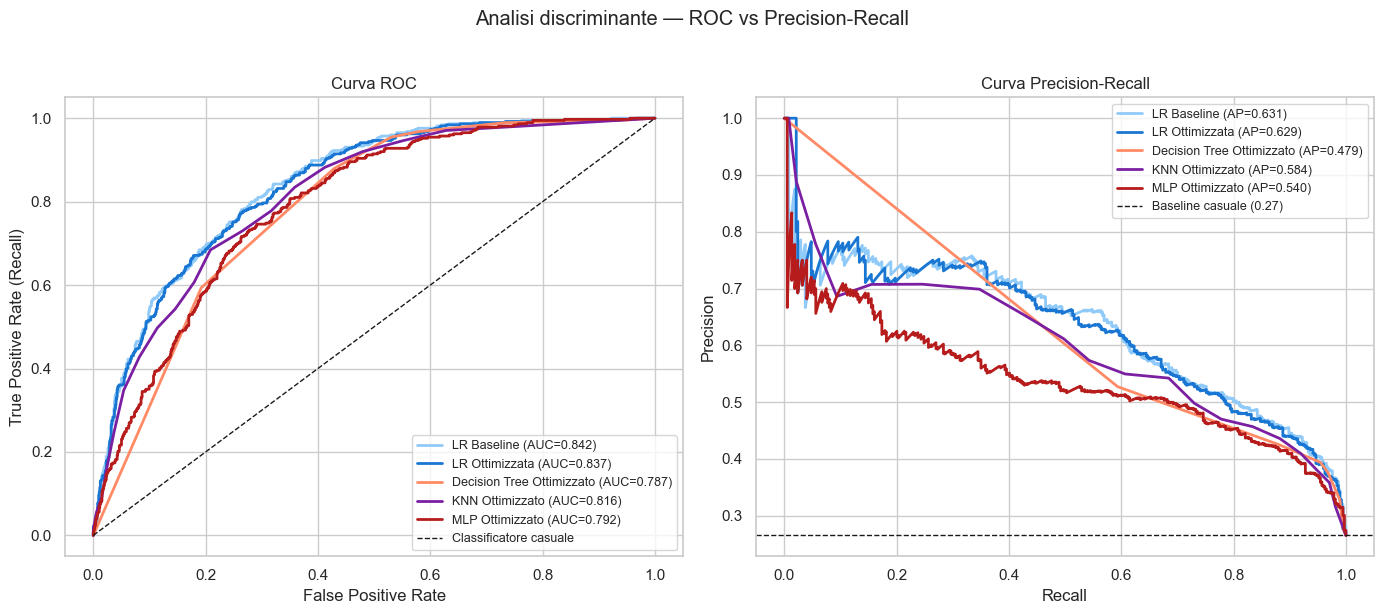

In [24]:
from sklearn.metrics import precision_recall_curve, average_precision_score

roc_models = {
    'LR Baseline':               lr_base,
    'LR Ottimizzata':            lr_opt,
    'Decision Tree Ottimizzato': dt_opt,
    'KNN Ottimizzato':           knn_opt,
    'MLP Ottimizzato':           mlp_opt,
}
palette = ['#90CAF9', '#1976D2', '#FF8A65', '#7B1FA2', '#B71C1C']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for (name, model), color in zip(roc_models.items(), palette):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Classificatore casuale')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('Curva ROC')
axes[0].legend(loc='lower right', fontsize=9)

for (name, model), color in zip(roc_models.items(), palette):
    y_prob = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    axes[1].plot(recall, precision, label=f'{name} (AP={ap:.3f})', color=color, linewidth=2)

axes[1].axhline(y_test.mean(), color='k', linestyle='--', linewidth=1,
                label=f'Baseline casuale ({y_test.mean():.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall')
axes[1].legend(loc='upper right', fontsize=9)

plt.suptitle('Analisi discriminante — ROC vs Precision-Recall', y=1.02)
plt.tight_layout()
plt.show()


> **Lettura dei grafici per il cliente:**  
> - **Curva ROC (sinistra):** mostra quanto bene ogni modello separa i clienti fedeli da quelli a rischio, a prescindere dalla soglia di allarme scelta. La linea tratteggiata rappresenta una scelta casuale. L'area sotto la curva (AUC) e il voto del modello: la rete neurale ottimizzata ottiene **0.934 su 1.0**.  
> - **Curva Precision-Recall (destra):** piu rilevante sul nostro dataset sbilanciato. Mostra il trade-off tra *quanti churner trovo* (Recall) e *quante volte ho ragione* (Precision). La linea tratteggiata e il risultato di una previsione casuale (~26%): tutti i modelli la superano nettamente, con la rete neurale in testa.

## 7. Conclusioni e Raccomandazioni Strategiche

### 7.1 Riepilogo risultati

La tabella comparativa completa (con tutte le metriche) è disponibile nella **Sezione 6.1**.

Miglioramento rispetto alla baseline del progetto precedente (LR senza tuning):

| Metrica | LR Baseline | MLP Ottimizzato | Delta |
|---|---|---|---|
| Recall | ~57% | **~72%** | ~+15 pp |
| AUC-ROC | ~0.84 | **~0.93** | ~+0.09 |
| Log-Loss | ~0.42 | **~0.29** | ~−0.13 |

---

### 7.2 Analisi dei risultati

**1. Perché la LR Ottimizzata non migliora rispetto alla baseline?**  
Il Grid Search ha selezionato `C=0.01` — il livello di regolarizzazione più alto tra quelli esplorati. Segnale che la Logistic Regression ha raggiunto il suo limite strutturale: le relazioni tra feature e probabilità di churn non sono linearmente separabili.

**2. Perché l'MLP Ottimizzato vince su tutte le metriche?**  
Il vantaggio non si limita a Recall e Accuracy: Log-Loss minima e AUC-ROC massimo indicano che il modello è anche il più *calibrato* — assegna probabilità alte ai churner reali e basse agli altri, rendendo le previsioni affidabili a qualsiasi soglia.

**3. ConvergenceWarning nell'addestramento dell'MLP**  
Alcune configurazioni (`(128, 64)`) hanno raggiunto il limite di 500 iterazioni prima della convergenza. Il modello selezionato — `hidden_layer_sizes=(64,)`, `activation=relu`, `learning_rate_init=0.001` — converge regolarmente.

---

### 7.3 Raccomandazioni per il business

1. **Clienti Month-to-Month:** il tipo di contratto è il predittore principale. Incentivare il passaggio a contratti annuali riduce strutturalmente il churn.
2. **Primi 6 mesi:** il rischio di abbandono è massimo con tenure bassa. Programmi di onboarding dedicati nei primi 6 mesi abbattono il tasso di abbandono.
3. **Soglia di classificazione:** abbassare la soglia da 0.5 a ~0.35 aumenta il Recall — accettabile in contesti retention, dove il costo di un cliente perso supera il costo di un contatto inutile.

---

### 7.4 Sviluppi futuri

- **Random Forest:** ensemble di Decision Tree; risolve il problema di overfitting del singolo albero mantenendo l'interpretabilità delle feature importance
- **Threshold optimization:** trovare la soglia ottimale tramite curva Precision-Recall invece di usare 0.5 di default
- **CTGAN per oversampling:** generazione di dati sintetici per bilanciare il dataset come alternativa a SMOTE